# Random Forest para fraude con tarjetas de credito

## 1. Setup de librerias y configuracion

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 120)


## 2. Generacion de datos sinteticos de transacciones

In [2]:

n = 20000
merchant_categories = ["groceries","electronics","fashion","gas","subscription","travel","restaurants","online_services"]
countries = ["SV","US","MX","CO","BR","ES","UK"]
device_types = ["mobile","desktop","pos"]
channels = ["online","pos"]

amount = np.random.lognormal(mean=3.3, sigma=0.9, size=n)
avg_amount_1m = np.random.lognormal(mean=3.1, sigma=0.7, size=n)
std_amount_1m = np.random.lognormal(mean=1.0, sigma=0.5, size=n)
distance_from_home = np.random.gamma(shape=2.0, scale=5.0, size=n)
past_tx_24h = np.random.poisson(lam=2.2, size=n)
declined_past_1w = np.random.poisson(lam=0.3, size=n)
card_age_months = np.clip(np.random.exponential(scale=24.0, size=n), 0, 120)
chargebacks_1y = np.random.binomial(n=3, p=0.05, size=n)
hour = np.random.randint(0, 24, size=n)
dow = np.random.randint(0, 7, size=n)

merchant_category = np.random.choice(merchant_categories, size=n, p=[0.18,0.10,0.12,0.10,0.08,0.10,0.18,0.14])
country = np.random.choice(countries, size=n, p=[0.55,0.12,0.07,0.06,0.05,0.08,0.07])
device = np.random.choice(device_types, size=n, p=[0.55,0.20,0.25])
channel = np.random.choice(channels, size=n, p=[0.45,0.55])

n_merchants = 1000
merchant_id = np.random.zipf(a=2.0, size=n)
merchant_id = np.clip(merchant_id, 1, n_merchants).astype(int).astype(str)

is_international = (country != "SV").astype(int)
is_night = ((hour >= 22) | (hour <= 5)).astype(int)

logit = (
    0.8 * (amount > (avg_amount_1m * 2)).astype(int)
    + 1.1 * is_international
    + 0.9 * (channel == "online").astype(int)
    + 0.7 * is_night
    + 0.6 * (np.isin(merchant_category, ["electronics","travel","online_services"]).astype(int))
    + 0.04 * (distance_from_home > 20).astype(int)
    + 0.5 * (declined_past_1w > 0).astype(int)
    + 0.6 * (chargebacks_1y > 0).astype(int)
    + 0.002 * (amount - avg_amount_1m)
    - 0.002 * card_age_months
)
logit = logit + np.random.normal(0, 0.5, size=n)
prob_fraud = 1 / (1 + np.exp(-logit))
prob_fraud = np.clip(prob_fraud * 0.35, 0, 1)
y = (np.random.rand(n) < prob_fraud).astype(int)

df = pd.DataFrame({
    "amount": amount,
    "avg_amount_1m": avg_amount_1m,
    "std_amount_1m": std_amount_1m,
    "distance_from_home": distance_from_home,
    "past_tx_24h": past_tx_24h,
    "declined_past_1w": declined_past_1w,
    "card_age_months": card_age_months,
    "chargebacks_1y": chargebacks_1y,
    "hour": hour,
    "dow": dow,
    "merchant_category": merchant_category,
    "country": country,
    "device": device,
    "channel": channel,
    "merchant_id": merchant_id,
    "is_international": is_international,
    "is_night": is_night,
    "is_fraud": y
})

df.head()


,amount,avg_amount_1m,std_amount_1m,distance_from_home,past_tx_24h,declined_past_1w,card_age_months,chargebacks_1y,hour,dow,merchant_category,country,device,channel,merchant_id,is_international,is_night,is_fraud
0,42.395522,28.326574,2.146999,8.852658,1,1,4.072781,0,19,2,online_services,SV,mobile,online,10,0,0,1
1,23.940274,27.067304,4.510244,12.520494,2,0,10.124881,0,17,1,gas,SV,mobile,pos,1,0,0,0
2,48.565805,11.524049,2.461834,7.188157,2,1,62.146665,0,7,3,groceries,US,pos,pos,7,1,0,0
3,106.775326,33.305047,2.844208,13.297110,1,0,12.196007,0,14,4,restaurants,SV,pos,pos,2,0,0,0
4,21.960864,7.822014,3.891113,11.316591,1,0,7.632915,0,18,1,groceries,SV,mobile,online,1,0,0,0


## 3. Valores faltantes

In [3]:

rng = np.random.default_rng(RANDOM_STATE)
for col in ["amount","avg_amount_1m","std_amount_1m","distance_from_home","past_tx_24h",
            "declined_past_1w","card_age_months","chargebacks_1y"]:
    mask = rng.random(len(df)) < 0.02
    df.loc[mask, col] = np.nan
for col in ["merchant_category","country","device","channel"]:
    mask = rng.random(len(df)) < 0.01
    df.loc[mask, col] = np.nan
df.isna().mean().sort_values(ascending=False)


card_age_months       0.02145
past_tx_24h           0.02060
avg_amount_1m         0.02035
declined_past_1w      0.02025
chargebacks_1y        0.02015
amount                0.02005
std_amount_1m         0.01955
distance_from_home    0.01900
channel               0.01125
merchant_category     0.00990
device                0.00905
country               0.00890
is_international      0.00000
is_night              0.00000
dow                   0.00000
merchant_id           0.00000
hour                  0.00000
is_fraud              0.00000
dtype: float64

## 4. EDA: normalidad, correlacion, varianza

In [4]:

num_cols_all = df.select_dtypes(include=[np.number]).columns.drop("is_fraud")
cat_cols_all = df.select_dtypes(exclude=[np.number]).columns

desc = df[num_cols_all].describe().T
desc


,count,mean,std,min,25%,50%,75%,max
amount,19599.0,41.002534,46.996423,0.794406,14.878657,27.329643,50.060127,1527.176410
avg_amount_1m,19593.0,28.078937,22.089161,0.974410,13.590490,22.065140,35.492022,301.715144
std_amount_1m,19609.0,3.087699,1.633742,0.317367,1.943925,2.729852,3.835656,17.684519
distance_from_home,19620.0,9.974675,7.017845,0.058725,4.823492,8.437691,13.369361,65.557427
past_tx_24h,19588.0,2.206810,1.491748,0.000000,1.000000,2.000000,3.000000,9.000000
declined_past_1w,19595.0,0.300230,0.547934,0.000000,0.000000,0.000000,1.000000,4.000000
card_age_months,19571.0,24.254855,23.526749,0.000134,7.020000,16.876888,33.656503,120.000000
chargebacks_1y,19597.0,0.151095,0.379459,0.000000,0.000000,0.000000,0.000000,3.000000
hour,20000.0,11.399300,6.900706,0.000000,5.000000,11.000000,17.000000,23.000000
dow,20000.0,3.008200,1.994676,0.000000,1.000000,3.000000,5.000000,6.000000


In [5]:

check_norm_cols = ["amount","avg_amount_1m","std_amount_1m","distance_from_home"]
rows = []
for col in check_norm_cols:
    series = df[col].dropna()
    sample = series.sample(n=min(5000, len(series)), random_state=RANDOM_STATE)
    sh_stat, sh_p = stats.shapiro(sample)
    k2_stat, k2_p = stats.normaltest(series.values, nan_policy='omit')
    rows.append({"col": col, "shapiro_p": sh_p, "dagostino_k2_p": k2_p})
pd.DataFrame(rows)


,col,shapiro_p,dagostino_k2_p
0,amount,6.022623e-72,0.0
1,avg_amount_1m,2.258512e-64,0.0
2,std_amount_1m,4.864662e-52,0.0
3,distance_from_home,1.883303e-48,0.0


In [6]:

corr = df[num_cols_all].corr(numeric_only=True)
corr


,amount,avg_amount_1m,std_amount_1m,distance_from_home,past_tx_24h,declined_past_1w,card_age_months,chargebacks_1y,hour,dow,is_international,is_night
amount,1.000000,0.018277,-0.007992,-0.000691,0.006065,0.002809,0.010198,-0.007379,-0.004395,0.005025,-0.011349,-0.004277
avg_amount_1m,0.018277,1.000000,-0.001962,0.014296,-0.005724,0.008061,0.000249,0.005720,-0.005360,-0.005269,-0.006289,0.008427
std_amount_1m,-0.007992,-0.001962,1.000000,0.008473,-0.008455,-0.005940,-0.017542,-0.010275,-0.004408,0.006382,-0.005261,-0.006192
distance_from_home,-0.000691,0.014296,0.008473,1.000000,0.005039,0.004566,-0.003200,0.003373,-0.000923,0.005715,0.015285,0.002073
past_tx_24h,0.006065,-0.005724,-0.008455,0.005039,1.000000,0.006240,0.005608,0.002539,-0.002489,0.005372,0.011234,-0.003437
declined_past_1w,0.002809,0.008061,-0.005940,0.004566,0.006240,1.000000,0.001847,0.013127,-0.003059,0.006549,0.012782,0.003905
card_age_months,0.010198,0.000249,-0.017542,-0.003200,0.005608,0.001847,1.000000,0.003931,0.012797,-0.019570,0.003698,-0.010006
chargebacks_1y,-0.007379,0.005720,-0.010275,0.003373,0.002539,0.013127,0.003931,1.000000,0.012866,-0.004592,0.015043,0.001132
hour,-0.004395,-0.005360,-0.004408,-0.000923,-0.002489,-0.003059,0.012797,0.012866,1.000000,-0.000616,-0.002073,-0.421193
dow,0.005025,-0.005269,0.006382,0.005715,0.005372,0.006549,-0.019570,-0.004592,-0.000616,1.000000,-0.005883,-0.010353


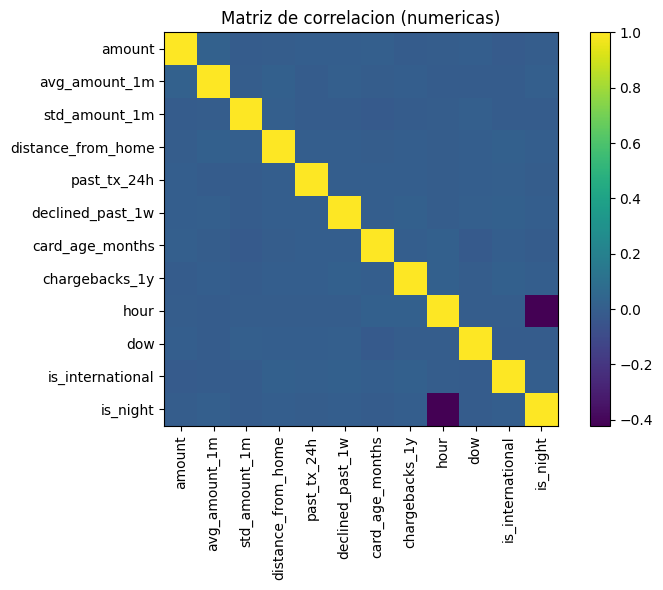

In [7]:

plt.figure(figsize=(8,6))
plt.imshow(corr, interpolation='nearest')
plt.title("Matriz de correlacion (numericas)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.tight_layout()
plt.show()


In [8]:

variances = df[num_cols_all].var(numeric_only=True).sort_values()
variances


chargebacks_1y           0.143989
is_night                 0.222704
is_international         0.247482
declined_past_1w         0.300232
past_tx_24h              2.225313
std_amount_1m            2.669112
dow                      3.978732
hour                    47.619740
distance_from_home      49.250150
avg_amount_1m          487.931036
card_age_months        553.507924
amount                2208.663797
dtype: float64

## 5. Preparacion de datos

In [9]:

X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", MinMaxScaler())])
categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocess = ColumnTransformer([("num", numeric_transformer, numeric_features), ("cat", categorical_transformer, categorical_features)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
X_train.shape, X_test.shape, y_train.mean(), y_test.mean()


((15000, 17), (5000, 17), 0.28873333333333334, 0.2886)

## 6. Baseline RF (gini)

In [10]:

rf_baseline = Pipeline([("prep", preprocess), ("rf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))])
rf_baseline.fit(X_train, y_train)
y_pred = rf_baseline.predict(X_test)
y_proba = rf_baseline.predict_proba(X_test)[:,1]

print("Reporte de clasificacion (baseline)\n")
print(classification_report(y_test, y_pred, digits=4))
print("AUC-ROC (baseline):", roc_auc_score(y_test, y_proba))

cm = confusion_matrix(y_test, y_pred)
cm


Reporte de clasificacion (baseline)

              precision    recall  f1-score   support

           0     0.7112    0.9975    0.8303      3557
           1     0.1818    0.0014    0.0028      1443

    accuracy                         0.7100      5000
   macro avg     0.4465    0.4994    0.4165      5000
weighted avg     0.5584    0.7100    0.5915      5000

AUC-ROC (baseline): 0.5354510670788433


array([[3548,    9],
       [1441,    2]], dtype=int64)

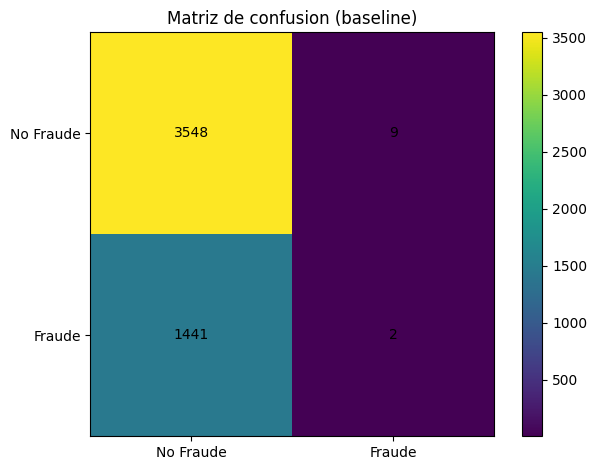

In [11]:

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Matriz de confusion (baseline)")
plt.xticks([0,1], ["No Fraude","Fraude"])
plt.yticks([0,1], ["No Fraude","Fraude"])
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()


## 7. RF con entropia y profundidad

In [12]:

rf_tuned_simple = Pipeline([("prep", preprocess), ("rf", RandomForestClassifier(n_estimators=400, max_depth=12, criterion="entropy", random_state=RANDOM_STATE, n_jobs=-1))])
rf_tuned_simple.fit(X_train, y_train)
y_pred2 = rf_tuned_simple.predict(X_test)
y_proba2 = rf_tuned_simple.predict_proba(X_test)[:,1]

print("Reporte de clasificacion (entropia, profundidad=12)\n")
print(classification_report(y_test, y_pred2, digits=4))
print("AUC-ROC:", roc_auc_score(y_test, y_proba2))

cm2 = confusion_matrix(y_test, y_pred2)
cm2


Reporte de clasificacion (entropia, profundidad=12)

              precision    recall  f1-score   support

           0     0.7114    1.0000    0.8314      3557
           1     0.0000    0.0000    0.0000      1443

    accuracy                         0.7114      5000
   macro avg     0.3557    0.5000    0.4157      5000
weighted avg     0.5061    0.7114    0.5914      5000

AUC-ROC: 0.5502930105122964


C:\virtual_environment\bootcamp03\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\virtual_environment\bootcamp03\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\virtual_environment\bootcamp03\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


array([[3557,    0],
       [1443,    0]], dtype=int64)

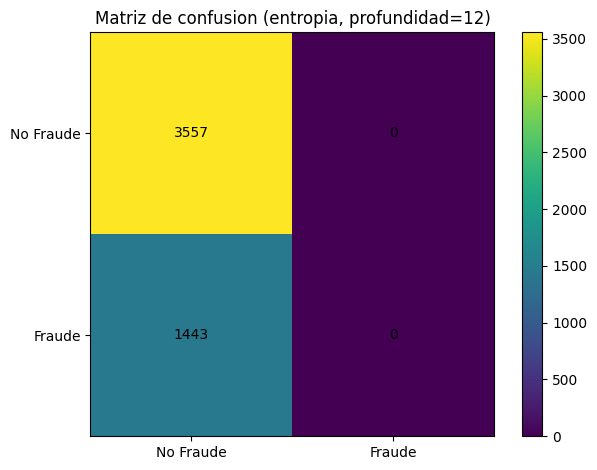

In [13]:

plt.figure()
plt.imshow(cm2, interpolation='nearest')
plt.title("Matriz de confusion (entropia, profundidad=12)")
plt.xticks([0,1], ["No Fraude","Fraude"])
plt.yticks([0,1], ["No Fraude","Fraude"])
plt.colorbar()
for i in range(cm2.shape[0]):
    for j in range(cm2.shape[1]):
        plt.text(j, i, cm2[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()


## 8. Busqueda de hiperparametros (RandomizedSearchCV)

In [14]:

param_distributions = {
    "rf__n_estimators": [200, 300, 400, 600],
    "rf__max_depth": [None, 10, 12, 16, 20],
    "rf__max_features": ["sqrt", 0.5, None],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__bootstrap": [True],
    "rf__criterion": ["gini", "entropy"]
}

rf_pipe = Pipeline([("prep", preprocess), ("rf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))])
search = RandomizedSearchCV(rf_pipe, param_distributions=param_distributions, n_iter=20, scoring="roc_auc", cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), random_state=RANDOM_STATE, n_jobs=-1, verbose=1)
search.fit(X_train, y_train)
search.best_params_, search.best_score_


Fitting 5 folds for each of 20 candidates, totalling 100 fits


KeyboardInterrupt: 

## 9. Modelo final con mejores hiperparametros

In [ ]:

best_model = search.best_estimator_
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:,1]

print("Reporte de clasificacion (mejores hiperparametros)\n")
print(classification_report(y_test, y_pred_best, digits=4))
print("AUC-ROC:", roc_auc_score(y_test, y_proba_best))

cm_best = confusion_matrix(y_test, y_pred_best)
cm_best


In [ ]:

plt.figure()
plt.imshow(cm_best, interpolation='nearest')
plt.title("Matriz de confusion (modelo final)")
plt.xticks([0,1], ["No Fraude","Fraude"])
plt.yticks([0,1], ["No Fraude","Fraude"])
plt.colorbar()
for i in range(cm_best.shape[0]):
    for j in range(cm_best.shape[1]):
        plt.text(j, i, cm_best[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()


### 9.1 Importancia de variables (top 20)

In [ ]:

prep = best_model.named_steps["prep"]
rf_final = best_model.named_steps["rf"]
num_names = numeric_features
cat_names = list(prep.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_features))
feature_names = num_names + cat_names

importances = rf_final.feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)
imp_df.head(20)


In [ ]:

top = imp_df.head(20).iloc[::-1]
plt.figure(figsize=(8,6))
plt.barh(top["feature"], top["importance"])
plt.title("Importancia de variables (top 20)")
plt.tight_layout()
plt.show()


## 10. Analisis OOB: accuracy y pureza

In [ ]:

best_params = search.best_estimator_.get_params()
oob_enabled_model = Pipeline([
    ("prep", preprocess),
    ("rf", RandomForestClassifier(
        n_estimators=best_params.get("rf__n_estimators", 400),
        max_depth=best_params.get("rf__max_depth", None),
        max_features=best_params.get("rf__max_features", "sqrt"),
        min_samples_split=best_params.get("rf__min_samples_split", 2),
        min_samples_leaf=best_params.get("rf__min_samples_leaf", 1),
        bootstrap=True,
        oob_score=True,
        criterion=best_params.get("rf__criterion", "gini"),
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])
oob_enabled_model.fit(X_train, y_train)
rf_oob = oob_enabled_model.named_steps["rf"]
print("OOB accuracy:", rf_oob.oob_score_)

oob_probs = rf_oob.oob_decision_function_
oob_df = pd.DataFrame(oob_probs, columns=[f"p_class_{c}" for c in rf_oob.classes_])
valid = ~oob_df.isna().any(axis=1)
oob_df_valid = oob_df[valid].copy()
oob_df_valid["purity"] = oob_df_valid.max(axis=1)
print("Pureza OOB (media):", round(oob_df_valid["purity"].mean(), 4))
print("Pureza OOB (mediana):", round(oob_df_valid["purity"].median(), 4))

plt.figure()
plt.hist(oob_df_valid["purity"], bins=40)
plt.title("Distribucion de pureza OOB")
plt.xlabel("pureza")
plt.ylabel("frecuencia")
plt.show()
